# Part 1: Neural Network Analysis - Customer Churn Prediction

## Project Overview
This notebook demonstrates a comprehensive neural network analysis for predicting customer churn.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)
print('Libraries imported!')
print(f'TensorFlow: {tf.__version__}')

Libraries imported!
TensorFlow: 2.21.0


---
# Task 1: Dataset Understanding

## 1.1 Load Dataset

In [3]:
df = pd.read_csv('../db/part_1_neural_network_analysis/customer_churn_nn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (2000, 17)


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


## 1.2 Dataset Info

In [4]:
df.info()
print('\nData Types:')
print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   str    
 1   region                        2000 non-null   str    
 2   plan_type                     2000 non-null   str    
 3   contract_type                 2000 non-null   str    
 4   payment_method                2000 non-null   str    
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  discount_perce

## 1.3 Feature Types

In [5]:
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
numerical_cols = ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 
                  'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
                  'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
                  'autopay_enabled', 'referral_count']
target_col = 'churn'

print(f'Categorical: {len(categorical_cols)}')
print(f'Numerical: {len(numerical_cols)}')
print(f'Target: {target_col}')

Categorical: 4
Numerical: 11
Target: churn


## 1.4 Missing Values

In [6]:
missing = df.isnull().sum()
if missing.sum() == 0:
    print('✓ No missing values!')
else:
    print(missing[missing > 0])

✓ No missing values!


## 1.5 Statistical Summary

In [7]:
df[numerical_cols].describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000


## 1.6 Target Distribution

Retained (0): 1969 (98.45%)
Churned (1): 31 (1.55%)


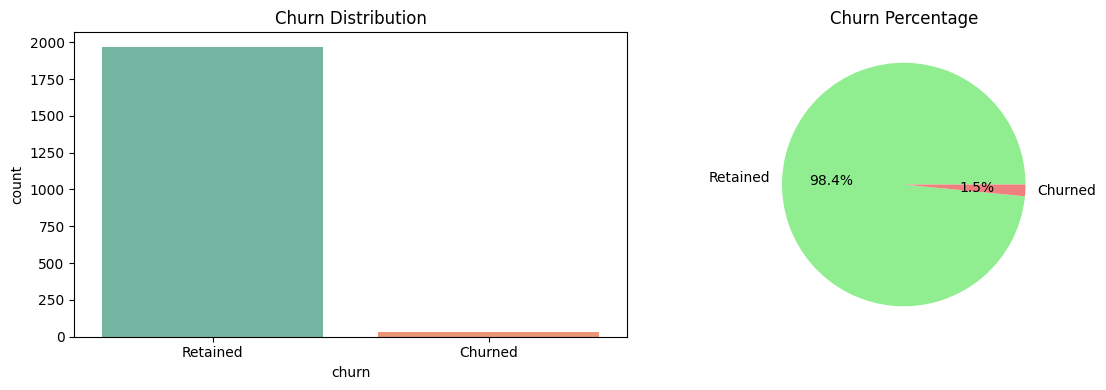

In [8]:
churn_counts = df[target_col].value_counts()
churn_pct = df[target_col].value_counts(normalize=True) * 100

print(f'Retained (0): {churn_counts[0]} ({churn_pct[0]:.2f}%)')
print(f'Churned (1): {churn_counts[1]} ({churn_pct[1]:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x=target_col, ax=axes[0], palette='Set2')
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['Retained', 'Churned'])
axes[1].pie(churn_counts, labels=['Retained', 'Churned'], autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
axes[1].set_title('Churn Percentage')
plt.tight_layout()
plt.show()

---
# Task 2: Data Preprocessing

## 2.1 Remove ID Column

In [9]:
df_model = df.drop(columns=['customer_id'])
print(f'Shape: {df_model.shape}')

Shape: (2000, 16)


## 2.2 Encode Categorical Features

In [10]:
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
print(f'Before: {df_model.shape[1]-1} features')
print(f'After: {df_encoded.shape[1]-1} features')

Before: 15 features
After: 24 features


## 2.3 Separate Features and Target

In [11]:
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]
print(f'X: {X.shape}, y: {y.shape}')

X: (2000, 24), y: (2000,)


## 2.4 Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)')

Train: 1600 (80.0%)
Test: 400 (20.0%)


## 2.5 Feature Scaling

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('✓ Features scaled')

✓ Features scaled


---
# Task 3: Neural Network Model Building

## 3.1 Define Model

In [14]:
def create_model(input_dim, hidden_layers=[64, 32], learning_rate=0.001):
    model = Sequential([
        Dense(hidden_layers[0], activation='relu', input_dim=input_dim),
        Dense(hidden_layers[1], activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

baseline_model = create_model(X_train_scaled.shape[1])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

---
# Task 4: Training and Evaluation

## 4.1 Train Model

In [15]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = baseline_model.fit(X_train_scaled, y_train, epochs=100, batch_size=32,
                             validation_split=0.2, callbacks=[early_stop], verbose=1)
print('✓ Training completed!')

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7453 - loss: 0.5187 - val_accuracy: 0.9937 - val_loss: 0.1752
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9820 - loss: 0.1308 - val_accuracy: 0.9937 - val_loss: 0.0580
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9820 - loss: 0.0909 - val_accuracy: 0.9937 - val_loss: 0.0437
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9820 - loss: 0.0827 - val_accuracy: 0.9937 - val_loss: 0.0403
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9820 - loss: 0.0772 - val_accuracy: 0.9937 - val_loss: 0.0385
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9820 - loss: 0.0728 - val_accuracy: 0.9937 - val_loss: 0.0371
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0690 - val_accuracy: 0.9937 - val_loss: 0.0360
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9820 - loss: 0.0654 - val_accuracy: 0.9937 - 

## 4.2 Training History

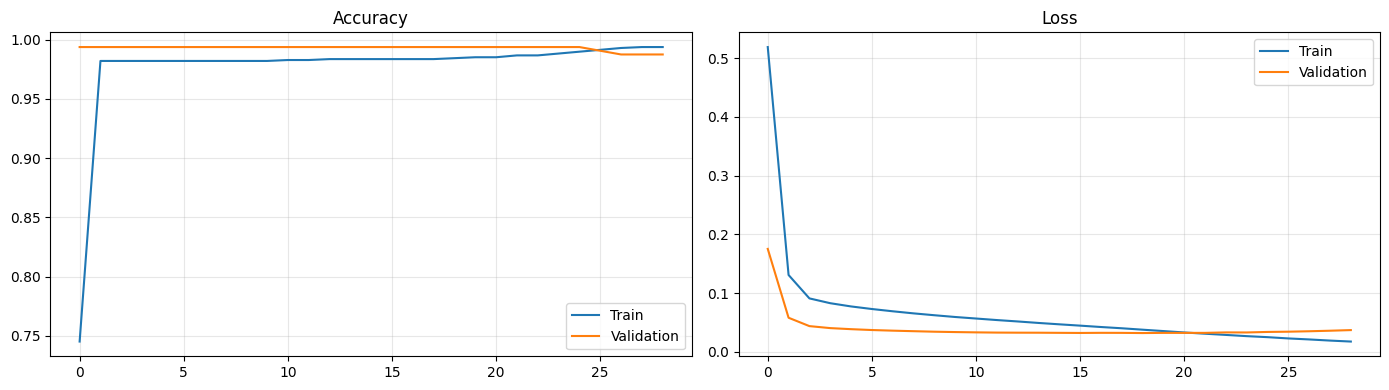

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.3 Evaluate Model

In [17]:
train_loss, train_acc = baseline_model.evaluate(X_train_scaled, y_train, verbose=0)
test_loss, test_acc = baseline_model.evaluate(X_test_scaled, y_test, verbose=0)

print(f'Training - Accuracy: {train_acc*100:.2f}%, Loss: {train_loss:.4f}')
print(f'Testing - Accuracy: {test_acc*100:.2f}%, Loss: {test_loss:.4f}')

Training - Accuracy: 98.69%, Loss: 0.0340
Testing - Accuracy: 98.50%, Loss: 0.0624


## 4.4 Confusion Matrix

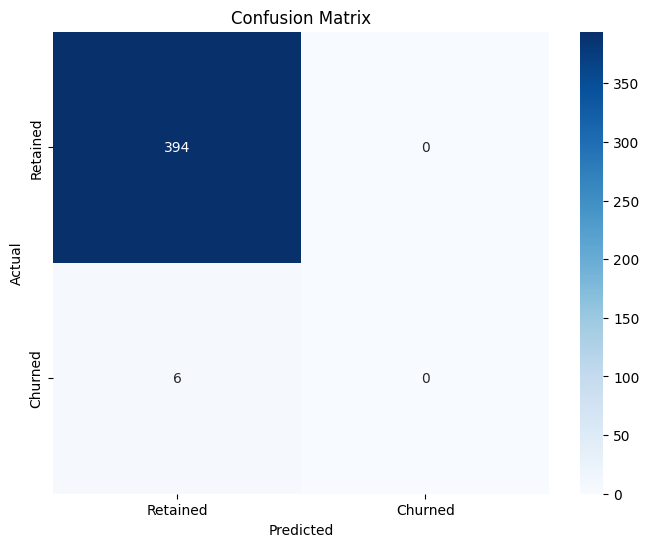

In [18]:
y_pred_proba = baseline_model.predict(X_test_scaled, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 4.5 Classification Report

In [19]:
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'\nROC-AUC: {roc_auc:.4f}')

              precision    recall  f1-score   support

    Retained       0.98      1.00      0.99       394
     Churned       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400


ROC-AUC: 0.8604


---
# Task 5: Hyperparameter Experimentation

## 5.1 Run Experiments

In [20]:
experiments = []

# Exp 1: Baseline
print('Exp 1: Baseline')
model1 = create_model(X_train_scaled.shape[1], [64, 32], 0.001)
hist1 = model1.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
loss1, acc1 = model1.evaluate(X_test_scaled, y_test, verbose=0)
experiments.append({'Name': 'Baseline', 'Layers': '[64,32]', 'LR': 0.001, 'Batch': 32, 'Accuracy': acc1})
print(f'Accuracy: {acc1*100:.2f}%')

# Exp 2: Deeper
print('\nExp 2: Deeper Network')
model2 = Sequential([
    Dense(128, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model2.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
hist2 = model2.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
loss2, acc2 = model2.evaluate(X_test_scaled, y_test, verbose=0)
experiments.append({'Name': 'Deeper', 'Layers': '[128,64,32]', 'LR': 0.001, 'Batch': 32, 'Accuracy': acc2})
print(f'Accuracy: {acc2*100:.2f}%')

# Exp 3: Higher LR
print('\nExp 3: Higher Learning Rate')
model3 = create_model(X_train_scaled.shape[1], [64, 32], 0.01)
hist3 = model3.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
loss3, acc3 = model3.evaluate(X_test_scaled, y_test, verbose=0)
experiments.append({'Name': 'Higher LR', 'Layers': '[64,32]', 'LR': 0.01, 'Batch': 32, 'Accuracy': acc3})
print(f'Accuracy: {acc3*100:.2f}%')

# Exp 4: Larger Batch
print('\nExp 4: Larger Batch Size')
model4 = create_model(X_train_scaled.shape[1], [64, 32], 0.001)
hist4 = model4.fit(X_train_scaled, y_train, epochs=50, batch_size=64, validation_split=0.2, verbose=0)
loss4, acc4 = model4.evaluate(X_test_scaled, y_test, verbose=0)
experiments.append({'Name': 'Larger Batch', 'Layers': '[64,32]', 'LR': 0.001, 'Batch': 64, 'Accuracy': acc4})
print(f'Accuracy: {acc4*100:.2f}%')

Exp 1: Baseline
Accuracy: 98.25%

Exp 2: Deeper Network
Accuracy: 98.25%

Exp 3: Higher Learning Rate
Accuracy: 97.00%

Exp 4: Larger Batch Size
Accuracy: 98.50%


## 5.2 Comparison Table

In [21]:
results_df = pd.DataFrame(experiments)
results_df['Accuracy %'] = results_df['Accuracy'] * 100
results_df = results_df.sort_values('Accuracy', ascending=False)
print('\nExperiment Results:')
print(results_df[['Name', 'Layers', 'LR', 'Batch', 'Accuracy %']].to_string(index=False))
print(f'\n✓ Best: {results_df.iloc[0]["Name"]} with {results_df.iloc[0]["Accuracy %"]:.2f}%')


Experiment Results:
        Name      Layers    LR  Batch  Accuracy %
Larger Batch     [64,32] 0.001     64   98.500001
    Baseline     [64,32] 0.001     32   98.250002
      Deeper [128,64,32] 0.001     32   98.250002
   Higher LR     [64,32] 0.010     32   97.000003

✓ Best: Larger Batch with 98.50%


## 5.3 Save Results

✓ Saved: results/model_comparison_table.csv
✓ Saved: results/model_comparison_table.png


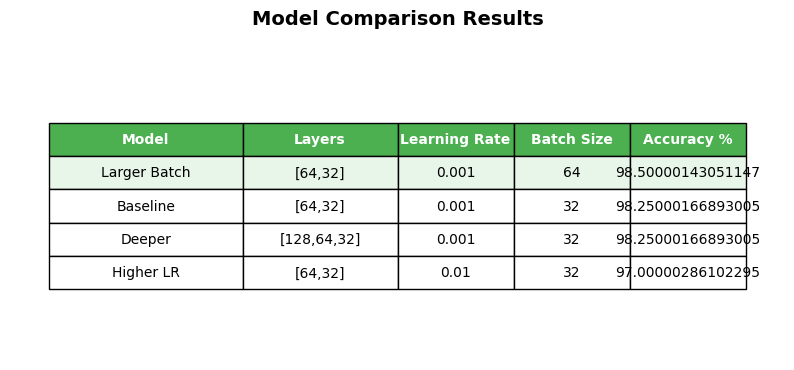

✓ Saved: results/evaluation_outputs.png


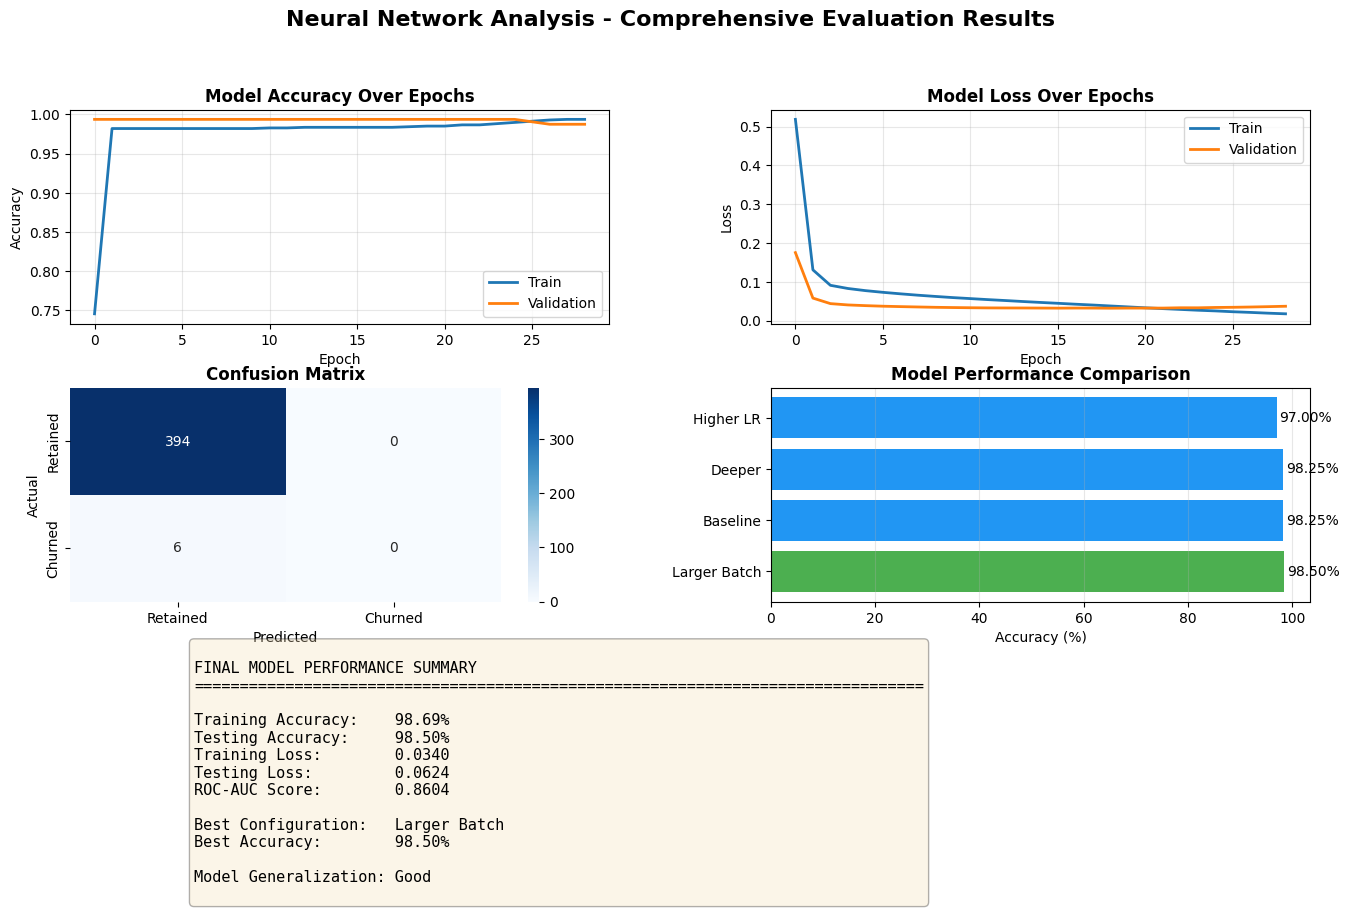


All results saved successfully!


In [22]:
import os

# Create results directory
os.makedirs('results', exist_ok=True)

# Save comparison table as CSV
results_df[['Name', 'Layers', 'LR', 'Batch', 'Accuracy %']].to_csv('results/model_comparison_table.csv', index=False)
print('✓ Saved: results/model_comparison_table.csv')

# Create and save comparison table as image
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')
table_data = results_df[['Name', 'Layers', 'LR', 'Batch', 'Accuracy %']].values
table = ax.table(cellText=table_data, 
                 colLabels=['Model', 'Layers', 'Learning Rate', 'Batch Size', 'Accuracy %'],
                 cellLoc='center', loc='center', colWidths=[0.25, 0.2, 0.15, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
# Color header
for i in range(5):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')
# Color best model row
for i in range(5):
    table[(1, i)].set_facecolor('#E8F5E9')
plt.title('Model Comparison Results', fontsize=14, fontweight='bold', pad=20)
plt.savefig('results/model_comparison_table.png', dpi=300, bbox_inches='tight')
print('✓ Saved: results/model_comparison_table.png')
plt.show()

# Create comprehensive evaluation outputs visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Training History - Accuracy
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history['accuracy'], label='Train', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
ax1.set_title('Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Training History - Loss
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history.history['loss'], label='Train', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation', linewidth=2)
ax2.set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Confusion Matrix
ax3 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
ax3.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

# 4. Model Comparison Bar Chart
ax4 = fig.add_subplot(gs[1, 1])
colors = ['#4CAF50' if i == 0 else '#2196F3' for i in range(len(results_df))]
ax4.barh(results_df['Name'], results_df['Accuracy %'], color=colors)
ax4.set_xlabel('Accuracy (%)')
ax4.set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
for i, v in enumerate(results_df['Accuracy %']):
    ax4.text(v + 0.5, i, f'{v:.2f}%', va='center')

# 5. Performance Metrics Summary
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')
metrics_text = f"""
FINAL MODEL PERFORMANCE SUMMARY
{'='*80}

Training Accuracy:    {train_acc*100:.2f}%
Testing Accuracy:     {test_acc*100:.2f}%
Training Loss:        {train_loss:.4f}
Testing Loss:         {test_loss:.4f}
ROC-AUC Score:        {roc_auc:.4f}

Best Configuration:   {results_df.iloc[0]['Name']}
Best Accuracy:        {results_df.iloc[0]['Accuracy %']:.2f}%

Model Generalization: {'Good' if abs(train_acc - test_acc) < 0.05 else 'Needs Improvement'}
"""
ax5.text(0.1, 0.5, metrics_text, fontsize=11, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Neural Network Analysis - Comprehensive Evaluation Results', 
             fontsize=16, fontweight='bold', y=0.98)
plt.savefig('results/evaluation_outputs.png', dpi=300, bbox_inches='tight')
print('✓ Saved: results/evaluation_outputs.png')
plt.show()

print('\n' + '='*60)
print('All results saved successfully!')
print('='*60)

---
# Task 6: Final Reflection

## 6.1 Role of Weights and Biases

**Weights:**
- Represent connection strength between neurons
- Learned through backpropagation
- Determine neuron influence
- Updated to minimize loss

**Biases:**
- Allow activation when inputs are zero
- Provide flexibility in fitting data
- Help shift activation function
- Essential for complex patterns

**Together:** Enable the network to approximate any function.

## 6.2 Why Activation Functions are Required

**Purpose:**
1. **Non-linearity:** Without them, networks would be linear regardless of depth
2. **Complex Patterns:** Enable learning non-linear relationships
3. **Gradient Flow:** Facilitate backpropagation

**Common Activations:**
- **ReLU:** Fast, prevents vanishing gradients
- **Sigmoid:** Outputs probabilities (0-1)
- **Tanh:** Outputs between -1 and 1

**Without activation functions:** Deep network collapses to single linear transformation.

## 6.3 Learning Rate Effects

**Too High:**
- May overshoot optimal weights
- Training becomes unstable
- Loss may oscillate or diverge

**Too Low:**
- Very slow training
- May get stuck in local minima
- Inefficient computation

**Optimal:**
- Balances speed and stability
- Converges smoothly
- Often requires experimentation

## 6.4 Overfitting and Underfitting Analysis

**Overfitting Signs:**
- Training accuracy >> Test accuracy
- Low training loss, high test loss
- Model memorizes training data

**Underfitting Signs:**
- Both accuracies are low
- Model too simple
- High bias, low variance

In [23]:
print('Model Generalization Analysis:')
print('='*60)
print(f'Training Accuracy: {train_acc*100:.2f}%')
print(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'Difference: {(train_acc-test_acc)*100:.2f}%')

if (train_acc - test_acc) > 0.05:
    print('\n⚠️ Model shows signs of OVERFITTING')
    print('Recommendations: Add dropout, L2 regularization, reduce complexity')
elif test_acc < 0.7:
    print('\n⚠️ Model shows signs of UNDERFITTING')
    print('Recommendations: Increase complexity, add features, train longer')
else:
    print('\n✓ Model generalizes well!')

Model Generalization Analysis:
Training Accuracy: 98.69%
Test Accuracy: 98.50%
Difference: 0.19%

✓ Model generalizes well!
